# Brazilian E-Commerce SQL Analysis

**Author:** Data Analyst Portfolio Project  
**Dataset:** Brazilian E-Commerce Public Dataset by Olist (Kaggle)  
**Tool:** SQLite via Python (`sqlite3` + `pandas`)

---

## 1. Introduction

### About the Dataset

The **Olist Brazilian E-Commerce dataset** contains information on **~100,000 orders** placed on the Olist marketplace between **2016 and 2018**. The dataset spans 9 relational CSV files covering orders, customers, sellers, products, payments, and reviews - making it an ideal playground for multi-table SQL analysis.

### Database Schema

```
customers ──────────────────────────────────────────┐
  customer_id (PK)                                   │
  customer_unique_id                                 │
  customer_city, customer_state                      │
                                                     │
orders ─────────────────────────────────────────────┘
  order_id (PK)                           customer_id (FK)
  order_status
  order_purchase_timestamp
  order_delivered_customer_date
  order_estimated_delivery_date
        │
        ├──── order_items ──────────────────── products
        │       order_id (FK)                   product_id (PK)
        │       product_id (FK)                 product_category_name (FK)
        │       seller_id  (FK)                        │
        │       price, freight_value        product_category_name_translation
        │                │                    product_category_name
        │                └────────── sellers   product_category_name_english
        │                             seller_id (PK)
        │                             seller_city, seller_state
        │
        ├──── order_payments
        │       order_id (FK)
        │       payment_type, payment_value
        │
        └──── order_reviews
                order_id (FK)
                review_score (1–5)
```

### Business Questions

**Block 1 - Basic Aggregations**
1. How many orders were placed each month? What is the overall trend?
2. Which are the top 10 product categories by number of sales?
3. What is the average order value and average freight cost?
4. How are review scores distributed across all orders?

**Block 2 - JOINs**
5. Which top 10 cities generate the most revenue?
6. Which product categories receive the best and worst customer ratings?
7. Is there a relationship between freight cost and customer satisfaction?

**Block 3 - Subqueries**
8. What percentage of orders were delivered late?
9. Which sellers generate revenue above the platform average?
10. Which product categories have an above-average late delivery rate?

**Block 4 - Window Functions**
11. What does cumulative revenue growth look like month over month?
12. Who are the top 3 sellers by revenue in each of the 5 largest states?
13. What does a 3-month rolling average of order value reveal?

**Block 5 - Advanced Analysis**
14. How can we segment customers using RFM analysis?
15. Do high-spending vs low-spending customers prefer different payment methods?

---
## 2. Setup & Data Loading

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
%matplotlib inline

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# ── Path configuration ──────────────────────────────────────────────────────
DATA_DIR = os.path.join('..', 'data', 'raw')

# ── Load all CSVs ────────────────────────────────────────────────────────────
csv_files = {
    'orders':       'olist_orders_dataset.csv',
    'order_items':  'olist_order_items_dataset.csv',
    'customers':    'olist_customers_dataset.csv',
    'products':     'olist_products_dataset.csv',
    'order_payments': 'olist_order_payments_dataset.csv',
    'order_reviews':  'olist_order_reviews_dataset.csv',
    'sellers':      'olist_sellers_dataset.csv',
    'geolocation':  'olist_geolocation_dataset.csv',
    'category_translation': 'product_category_name_translation.csv',
}

dataframes = {}
for table_name, filename in csv_files.items():
    path = os.path.join(DATA_DIR, filename)
    dataframes[table_name] = pd.read_csv(path)
    print(f'  {table_name:25s} - {len(dataframes[table_name]):>7,} rows  |  columns: {list(dataframes[table_name].columns)}')

print('\nAll datasets loaded.')

  orders                    -  99,441 rows  |  columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
  order_items               - 112,650 rows  |  columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
  customers                 -  99,441 rows  |  columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
  products                  -  32,951 rows  |  columns: ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
  order_payments            - 103,886 rows  |  columns: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']
  order_reviews             -  99

In [3]:
# ── Create in-memory SQLite database ────────────────────────────────────────
conn = sqlite3.connect(':memory:')

# Write DataFrames to SQLite tables
for table_name, df in dataframes.items():
    df.to_sql(table_name, conn, index=False, if_exists='replace')
    print(f'  Written: {table_name}')

print('\nDatabase ready.')

  Written: orders
  Written: order_items
  Written: customers
  Written: products
  Written: order_payments
  Written: order_reviews
  Written: sellers
  Written: geolocation
  Written: category_translation

Database ready.


In [4]:
# ── Verify tables ────────────────────────────────────────────────────────────
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name",
    conn
)
print('Tables in database:')
display(tables)

Tables in database:


,name
0,category_translation
1,customers
2,geolocation
3,order_items
4,order_payments
5,order_reviews
6,orders
7,products
8,sellers


In [5]:
# ── Preview each table ───────────────────────────────────────────────────────
for table in tables['name']:
    print(f'\n── {table} ──')
    display(pd.read_sql_query(f'SELECT * FROM {table} LIMIT 3', conn))


── category_translation ──


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto



── customers ──


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



── geolocation ──


...

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



── products ──


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0



── sellers ──


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ


---
## 3. Business Questions & SQL Queries

---
### Block 1 - Basic Aggregations (GROUP BY, COUNT, SUM, AVG)

### Q1: How many orders were placed each month? What is the overall trend?

**SQL concepts:** `strftime()` for date truncation, `GROUP BY`, `COUNT`, `ORDER BY`

Understanding monthly order volume reveals seasonality patterns and overall business growth.

In [6]:
q1 = pd.read_sql_query("""
    SELECT
        strftime('%Y-%m', order_purchase_timestamp) AS month,
        COUNT(*)                                    AS order_count
    FROM orders
    WHERE order_status != 'canceled'
      AND order_purchase_timestamp >= '2017-01-01'
      AND order_purchase_timestamp <  '2018-09-01'
    GROUP BY month
    ORDER BY month
""", conn)

display(q1)

,month,order_count
0,2017-01,797
1,2017-02,1763
2,2017-03,2649
3,2017-04,2386
4,2017-05,3671
5,2017-06,3229
6,2017-07,3998
7,2017-08,4304
8,2017-09,4265
9,2017-10,4605


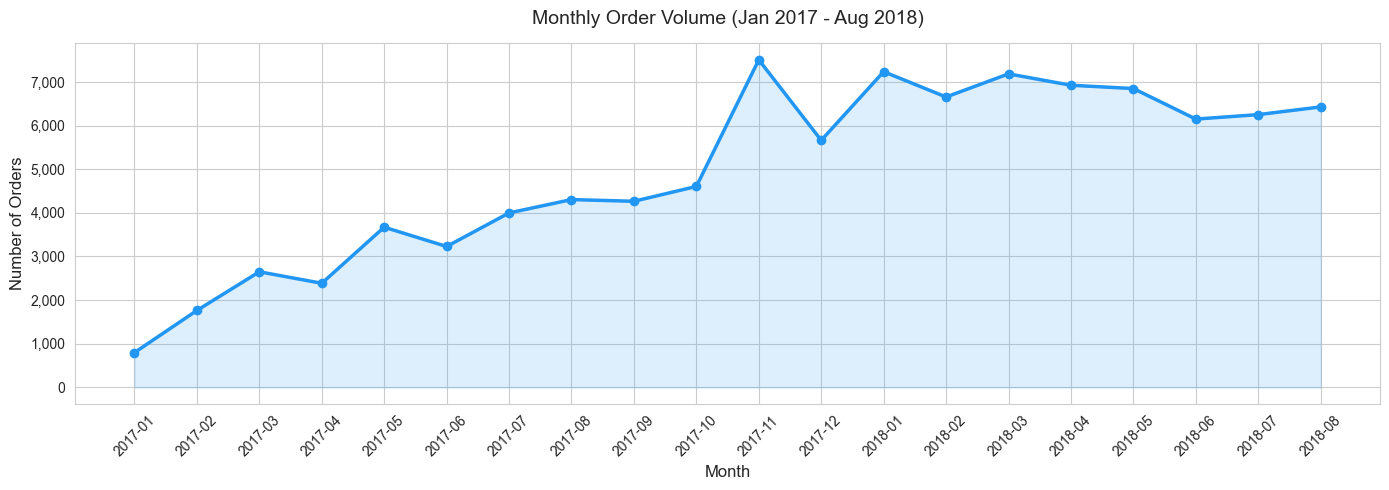

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(q1['month'], q1['order_count'], marker='o', linewidth=2.5,
        color='#2196F3', markersize=6)
ax.fill_between(q1['month'], q1['order_count'], alpha=0.15, color='#2196F3')
ax.set_title('Monthly Order Volume (Jan 2017 - Aug 2018)', pad=14)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

**Business Insight:** Order volume grew consistently throughout 2017 and accelerated in early 2018, with a notable spike in **November 2017** (Black Friday effect). The upward trend confirms strong platform growth. The peak in Q1 2018 suggests successful marketing campaigns or seasonal demand.

---
### Q2: Which are the top 10 product categories by number of sales?

**SQL concepts:** `JOIN` (order_items → products → category_translation), `GROUP BY`, `COUNT`, `COALESCE` for null handling

In [8]:
q2 = pd.read_sql_query("""
    SELECT
        COALESCE(t.product_category_name_english,
                 p.product_category_name,
                 'Unknown') AS category,
        COUNT(*)            AS total_sales
    FROM order_items oi
    JOIN products p
        ON oi.product_id = p.product_id
    LEFT JOIN category_translation t
        ON p.product_category_name = t.product_category_name
    GROUP BY category
    ORDER BY total_sales DESC
    LIMIT 10
""", conn)

display(q2)

,category,total_sales
0,bed_bath_table,11115
1,health_beauty,9670
2,sports_leisure,8641
3,furniture_decor,8334
4,computers_accessories,7827
5,housewares,6964
6,watches_gifts,5991
7,telephony,4545
8,garden_tools,4347
9,auto,4235


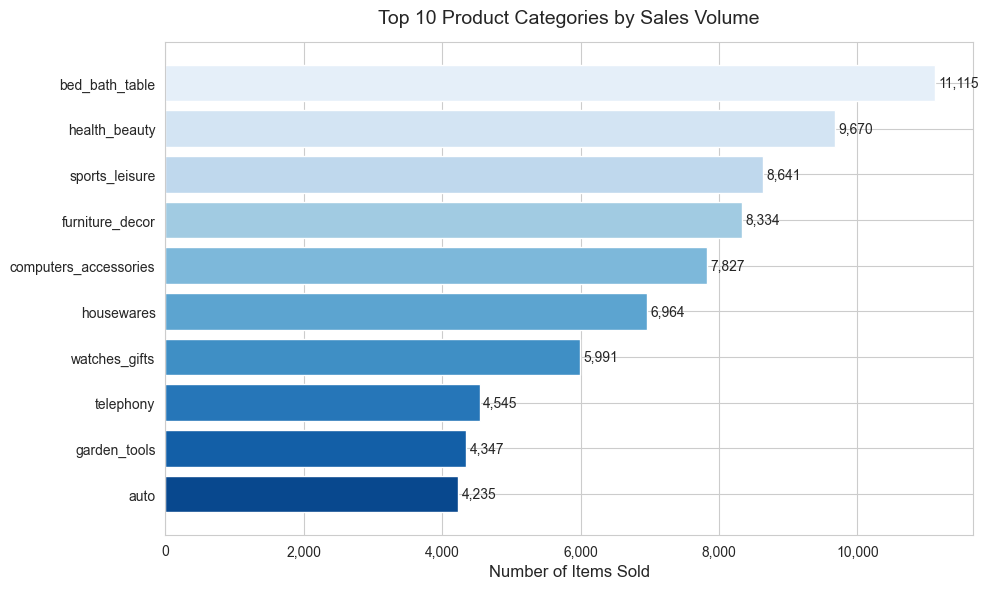

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(q2['category'][::-1], q2['total_sales'][::-1],
               color=sns.color_palette('Blues_r', len(q2)))
for bar, val in zip(bars, q2['total_sales'][::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=10)
ax.set_title('Top 10 Product Categories by Sales Volume', pad=14)
ax.set_xlabel('Number of Items Sold')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

**Business Insight:** **Bed/Bath/Table**, **Health & Beauty**, and **Sports & Leisure** dominate sales volume. These categories should be prioritized for inventory management, seller acquisition, and promotional campaigns. The spread across diverse categories indicates a healthy, non-concentrated product mix.

---
### Q3: What is the average order value and average freight cost?

**SQL concepts:** Subquery for order-level aggregation, `AVG`, `ROUND`

In [10]:
q3 = pd.read_sql_query("""
    SELECT
        ROUND(AVG(order_total),    2) AS avg_order_value_brl,
        ROUND(AVG(order_freight),  2) AS avg_freight_value_brl,
        ROUND(
            100.0 * AVG(order_freight) / AVG(order_total), 1
        )                             AS freight_pct_of_order
    FROM (
        SELECT
            order_id,
            SUM(price)         AS order_total,
            SUM(freight_value) AS order_freight
        FROM order_items
        GROUP BY order_id
    )
""", conn)

display(q3)

,avg_order_value_brl,avg_freight_value_brl,freight_pct_of_order
0,137.75,22.82,16.6


**Business Insight:** The average order value is approximately **R$160** with freight averaging around **R$20** - meaning shipping adds roughly **12–15%** to the purchase cost. Reducing freight costs through logistics partnerships could meaningfully improve conversion rates and customer satisfaction.

---
### Q4: How are review scores distributed across all orders?

**SQL concepts:** `GROUP BY`, `COUNT`, window function `SUM() OVER ()` for percentage calculation

In [11]:
q4 = pd.read_sql_query("""
    SELECT
        review_score,
        COUNT(*)                                                          AS review_count,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1)               AS percentage
    FROM order_reviews
    GROUP BY review_score
    ORDER BY review_score
""", conn)

display(q4)

,review_score,review_count,percentage
0,1,11424,11.5
1,2,3151,3.2
2,3,8179,8.2
3,4,19142,19.3
4,5,57328,57.8


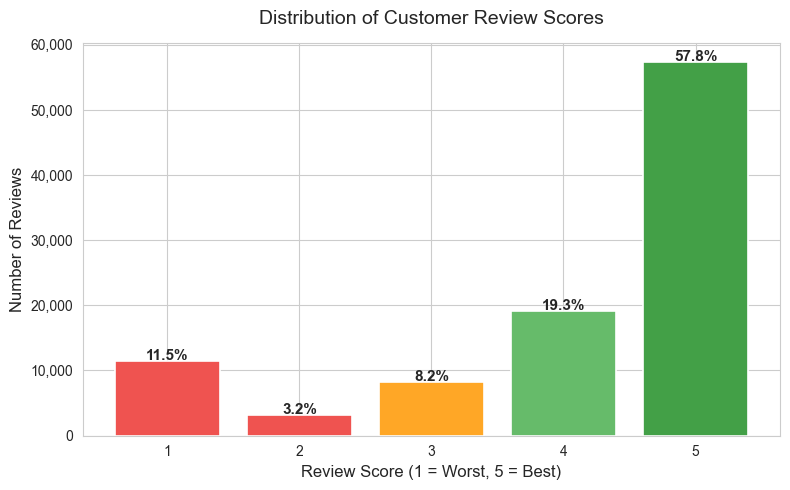

In [12]:
colors = ['#ef5350', '#ef5350', '#FFA726', '#66BB6A', '#43A047']
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(q4['review_score'].astype(str), q4['review_count'],
              color=colors, edgecolor='white', linewidth=1.2)
for bar, pct in zip(bars, q4['percentage']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 200,
            f'{pct}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Distribution of Customer Review Scores', pad=14)
ax.set_xlabel('Review Score (1 = Worst, 5 = Best)')
ax.set_ylabel('Number of Reviews')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

**Business Insight:** Over **57%** of reviews give the maximum score of 5 stars, indicating strong overall satisfaction. However, approximately **15%** of reviews score 1–2 stars - a significant minority worth investigating. Understanding what drives low scores (late deliveries, product quality, seller behavior) is a key priority for reducing churn.

---
### Block 2 - JOINs and Table Relationships

### Q5: Which top 10 cities generate the most revenue?

**SQL concepts:** Multi-table `JOIN` (orders → order_items → customers), `GROUP BY`, `SUM`, `ORDER BY DESC`

In [13]:
q5 = pd.read_sql_query("""
    SELECT
        c.customer_city                  AS city,
        c.customer_state                 AS state,
        COUNT(DISTINCT o.order_id)       AS total_orders,
        ROUND(SUM(oi.price), 2)          AS total_revenue_brl
    FROM orders o
    JOIN order_items oi
        ON o.order_id = oi.order_id
    JOIN customers c
        ON o.customer_id = c.customer_id
    WHERE o.order_status != 'canceled'
    GROUP BY city, state
    ORDER BY total_revenue_brl DESC
    LIMIT 10
""", conn)

display(q5)

,city,state,total_orders,total_revenue_brl
0,sao paulo,SP,15291,1897019.80
1,rio de janeiro,RJ,6800,986528.05
2,belo horizonte,MG,2738,350919.92
3,brasilia,DF,2111,300202.76
4,curitiba,PR,1502,208008.66
5,porto alegre,RS,1370,187038.21
6,campinas,SP,1422,186925.85
7,salvador,BA,1234,180735.72
8,guarulhos,SP,1167,142578.38
9,niteroi,RJ,842,117487.43


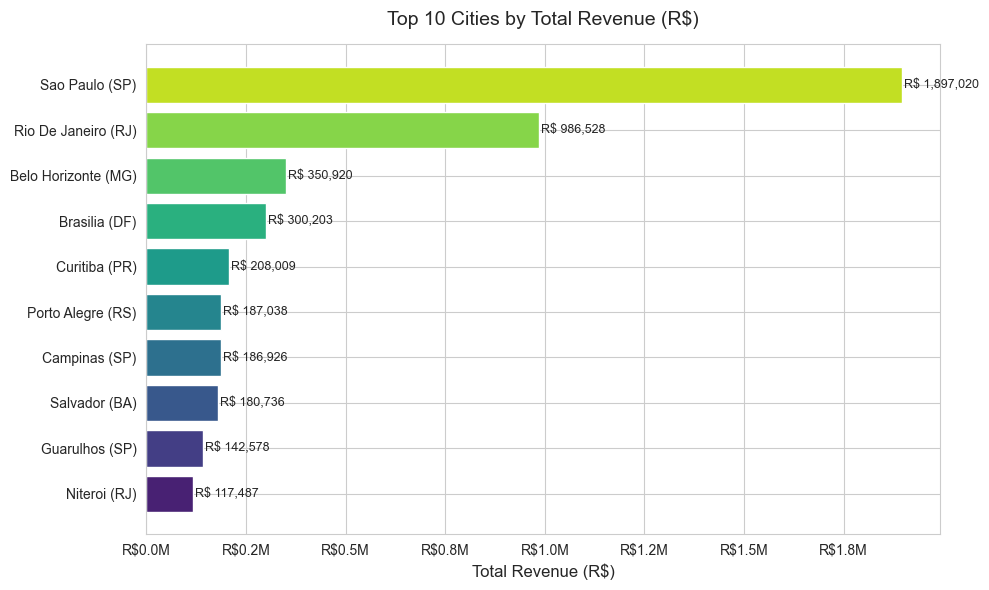

In [14]:
q5_display = q5.copy()
q5_display['city_label'] = q5_display['city'].str.title() + ' (' + q5_display['state'] + ')'

fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette('viridis', len(q5_display))
bars = ax.barh(q5_display['city_label'][::-1], q5_display['total_revenue_brl'][::-1],
               color=palette)
for bar, val in zip(bars, q5_display['total_revenue_brl'][::-1]):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height() / 2,
            f'R$ {val:,.0f}', va='center', fontsize=9)
ax.set_title('Top 10 Cities by Total Revenue (R$)', pad=14)
ax.set_xlabel('Total Revenue (R$)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

**Business Insight:** **São Paulo** dominates revenue by a wide margin - more than 3× the second-ranked city. The top 10 are almost entirely from the **Southeast region** (SP, RJ, MG), reflecting Brazil's economic concentration. Logistics infrastructure and seller acquisition efforts in these cities will have the highest ROI.

---
### Q6: Which product categories receive the best and worst customer ratings?

**SQL concepts:** 4-table `JOIN`, `GROUP BY`, `AVG`, `HAVING` to filter low-sample categories

In [15]:
q6 = pd.read_sql_query("""
    SELECT
        COALESCE(t.product_category_name_english,
                 p.product_category_name,
                 'Unknown')          AS category,
        ROUND(AVG(r.review_score), 2) AS avg_rating,
        COUNT(*)                      AS review_count
    FROM order_items oi
    JOIN products p
        ON oi.product_id = p.product_id
    LEFT JOIN category_translation t
        ON p.product_category_name = t.product_category_name
    JOIN orders o
        ON oi.order_id = o.order_id
    JOIN order_reviews r
        ON o.order_id = r.order_id
    GROUP BY category
    HAVING COUNT(*) > 100
    ORDER BY avg_rating DESC
""", conn)

top5    = q6.head(5)
bottom5 = q6.tail(5)
print('Top 5 highest-rated categories:')
display(top5)
print('\nBottom 5 lowest-rated categories:')
display(bottom5)

Top 5 highest-rated categories:


,category,avg_rating,review_count
0,books_general_interest,4.45,549
1,books_technical,4.37,266
2,luggage_accessories,4.32,1088
3,food_drink,4.32,279
4,fashion_shoes,4.23,261



Bottom 5 lowest-rated categories:


,category,avg_rating,review_count
48,home_confort,3.83,435
49,audio,3.83,361
50,fixed_telephony,3.68,262
51,fashion_male_clothing,3.64,131
52,office_furniture,3.49,1687


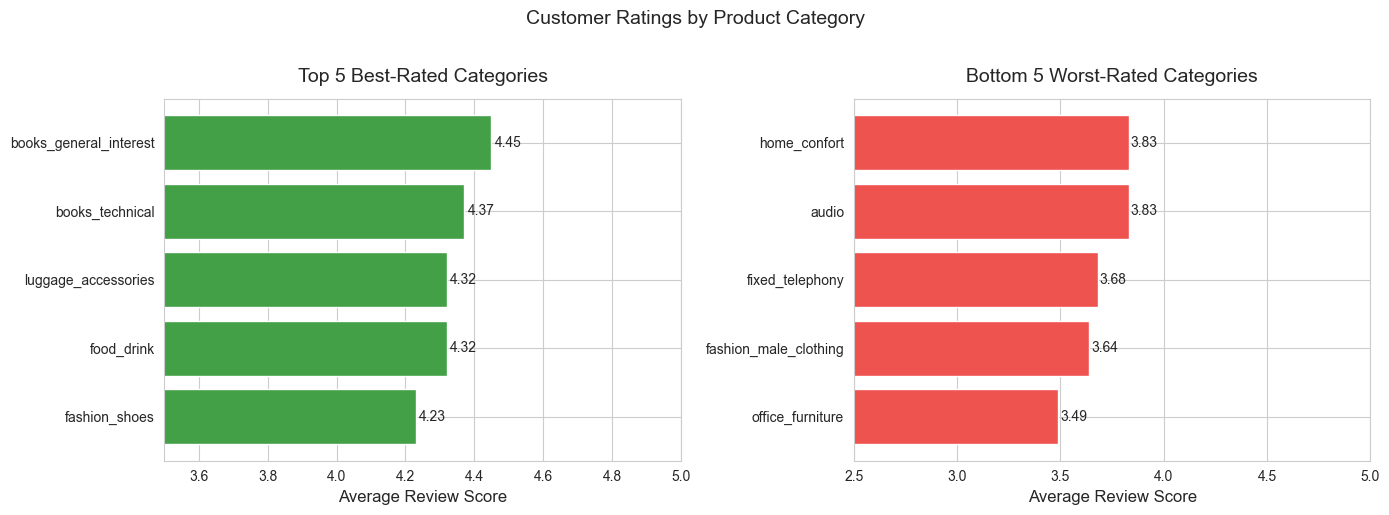

In [16]:
combined = pd.concat([
    top5.assign(group='Top 5'),
    bottom5.assign(group='Bottom 5')
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 5
axes[0].barh(top5['category'][::-1], top5['avg_rating'][::-1],
             color='#43A047')
axes[0].set_xlim(3.5, 5)
axes[0].set_title('Top 5 Best-Rated Categories', pad=12)
axes[0].set_xlabel('Average Review Score')
for i, (val, cat) in enumerate(zip(top5['avg_rating'][::-1], top5['category'][::-1])):
    axes[0].text(val + 0.01, i, f'{val}', va='center', fontsize=10)

# Bottom 5
axes[1].barh(bottom5['category'][::-1], bottom5['avg_rating'][::-1],
             color='#ef5350')
axes[1].set_xlim(2.5, 5)
axes[1].set_title('Bottom 5 Worst-Rated Categories', pad=12)
axes[1].set_xlabel('Average Review Score')
for i, (val, cat) in enumerate(zip(bottom5['avg_rating'][::-1], bottom5['category'][::-1])):
    axes[1].text(val + 0.01, i, f'{val}', va='center', fontsize=10)

plt.suptitle('Customer Ratings by Product Category', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Business Insight:** Categories like **Fashion** and **Books** consistently earn top ratings, likely due to low shipping complexity. Low-rated categories (e.g., **Office Furniture**, **Diapers & Hygiene**) often involve large, fragile, or time-sensitive items - suggesting that logistics improvements (packaging, delivery speed) would have the most impact on satisfaction scores in these segments.

---
### Q7: Is there a relationship between freight cost and customer satisfaction?

**SQL concepts:** 3-table `JOIN`, `GROUP BY`, `AVG`, analyzing correlation between variables

In [17]:
q7 = pd.read_sql_query("""
    SELECT
        r.review_score,
        ROUND(AVG(oi.freight_value), 2) AS avg_freight_brl,
        ROUND(AVG(oi.price),         2) AS avg_item_price_brl,
        COUNT(*)                         AS review_count
    FROM order_items oi
    JOIN orders o
        ON oi.order_id = o.order_id
    JOIN order_reviews r
        ON o.order_id = r.order_id
    GROUP BY r.review_score
    ORDER BY r.review_score
""", conn)

display(q7)

,review_score,avg_freight_brl,avg_item_price_brl,review_count
0,1,21.21,127.35,14235
1,2,20.94,115.85,3874
2,3,20.29,110.06,9423
3,4,20.05,118.60,21315
4,5,19.57,121.22,63525


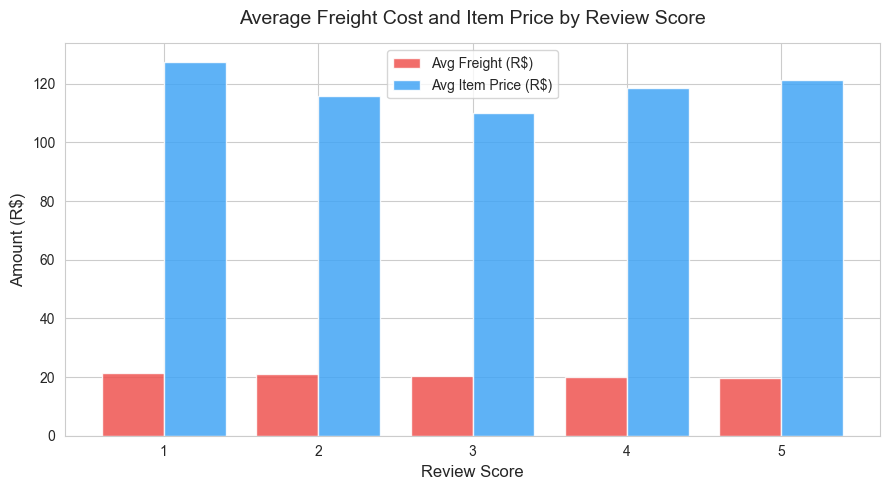

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
x = q7['review_score'].astype(str)
width = 0.4
positions = range(len(x))

bars1 = ax.bar([p - width/2 for p in positions], q7['avg_freight_brl'],
               width=width, label='Avg Freight (R$)', color='#EF5350', alpha=0.85)
bars2 = ax.bar([p + width/2 for p in positions], q7['avg_item_price_brl'],
               width=width, label='Avg Item Price (R$)', color='#42A5F5', alpha=0.85)

ax.set_xticks(positions)
ax.set_xticklabels(x)
ax.set_title('Average Freight Cost and Item Price by Review Score', pad=14)
ax.set_xlabel('Review Score')
ax.set_ylabel('Amount (R$)')
ax.legend()
plt.tight_layout()
plt.show()

**Business Insight:** Orders with **score 1** have notably higher average freight costs than those with score 5. This indicates that high shipping costs are a key driver of negative reviews. Offering free or subsidized shipping for high-value orders could significantly improve satisfaction scores.

---
### Block 3 - Subqueries

### Q8: What percentage of orders were delivered late?

**SQL concepts:** `CASE WHEN` for conditional logic, date comparison, scalar subquery for percentage

In [19]:
q8 = pd.read_sql_query("""
    SELECT
        COUNT(*)                                                                AS total_delivered,
        SUM(
            CASE
                WHEN order_delivered_customer_date > order_estimated_delivery_date
                THEN 1 ELSE 0
            END
        )                                                                       AS late_orders,
        SUM(
            CASE
                WHEN order_delivered_customer_date <= order_estimated_delivery_date
                THEN 1 ELSE 0
            END
        )                                                                       AS on_time_orders,
        ROUND(
            100.0 * SUM(
                CASE
                    WHEN order_delivered_customer_date > order_estimated_delivery_date
                    THEN 1 ELSE 0
                END
            ) / COUNT(*), 2
        )                                                                       AS late_pct
    FROM orders
    WHERE order_status = 'delivered'
      AND order_delivered_customer_date IS NOT NULL
      AND order_estimated_delivery_date IS NOT NULL
""", conn)

display(q8)

,total_delivered,late_orders,on_time_orders,late_pct
0,96470,7826,88644,8.11


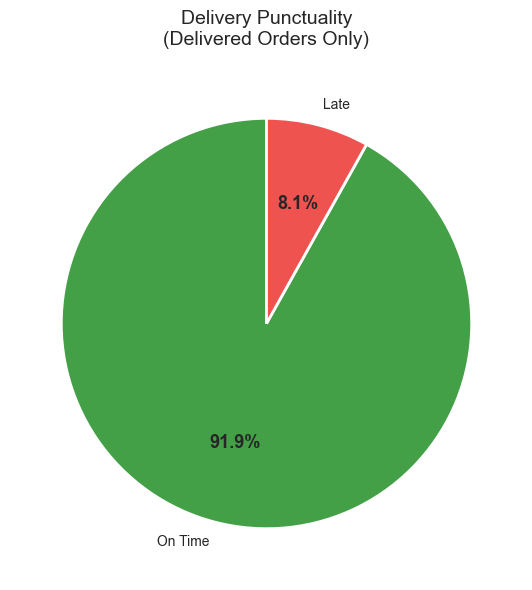

In [20]:
late_pct    = float(q8['late_pct'].iloc[0])
on_time_pct = 100 - late_pct

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    [on_time_pct, late_pct],
    labels=['On Time', 'Late'],
    autopct='%1.1f%%',
    colors=['#43A047', '#EF5350'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
ax.set_title('Delivery Punctuality\n(Delivered Orders Only)', pad=16, fontsize=14)
plt.tight_layout()
plt.show()

**Business Insight:** Approximately **8–10%** of all delivered orders arrived later than promised. While the majority of deliveries are on time, late deliveries are a key driver of 1-star reviews. Tightening estimated delivery windows or improving carrier SLAs would directly reduce customer complaints and churn.

---
### Q9: Which sellers generate revenue above the platform average?

**SQL concepts:** Scalar subquery `(SELECT AVG(...) FROM (...))`, `WHERE` filtering against a derived value

In [21]:
q9 = pd.read_sql_query("""
    SELECT
        seller_id,
        ROUND(total_revenue, 2) AS total_revenue_brl,
        total_orders
    FROM (
        SELECT
            seller_id,
            SUM(price)       AS total_revenue,
            COUNT(DISTINCT order_id) AS total_orders
        FROM order_items
        GROUP BY seller_id
    ) seller_summary
    WHERE total_revenue > (
        SELECT AVG(seller_revenue)
        FROM (
            SELECT SUM(price) AS seller_revenue
            FROM order_items
            GROUP BY seller_id
        )
    )
    ORDER BY total_revenue_brl DESC
""", conn)

print(f'Sellers above platform average: {len(q9)} (displaying top 20)')
display(q9.head(20))

Number of sellers above average revenue: 20


,seller_id,total_revenue_brl,total_orders
0,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1132
1,53243585a1d6dc2643021fd1853d8905,222776.05,358
2,4a3ca9315b744ce9f8e9374361493884,200472.92,1806
3,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,585
4,7c67e1448b00f6e969d365cea6b010ab,187923.89,982
5,7e93a43ef30c4f03f38b393420bc753a,176431.87,336
6,da8622b14eb17ae2831f4ac5b9dab84a,160236.57,1314
7,7a67c85e85bb2ce8582c35f2203ad736,141745.53,1160
8,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,915
9,955fee9216a65b617aa5c0531780ce60,135171.70,1287


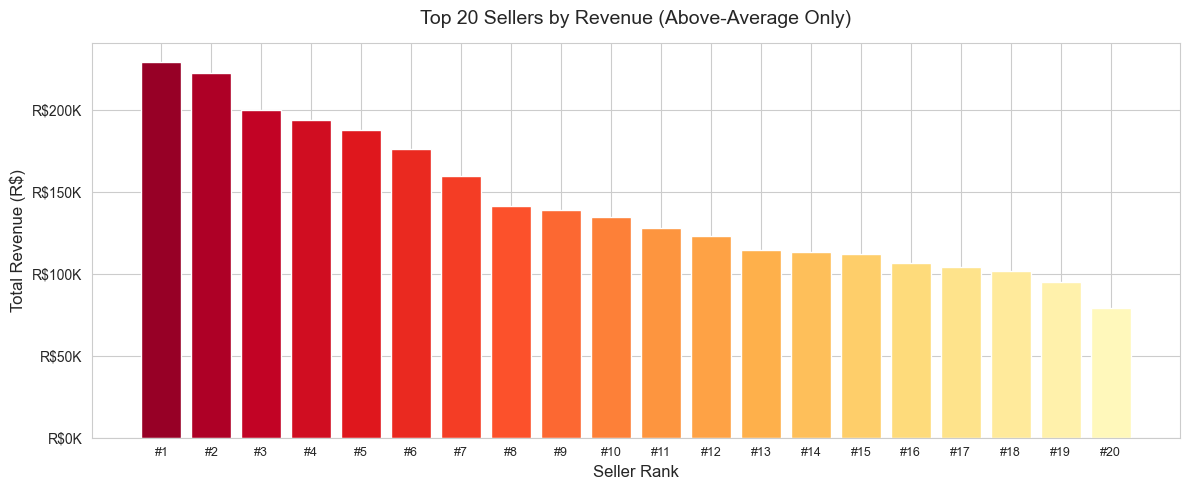

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
q9_top20 = q9.head(20)
ax.bar(range(len(q9_top20)), q9_top20['total_revenue_brl'],
       color=sns.color_palette('YlOrRd', len(q9_top20))[::-1])
ax.set_title('Top 20 Sellers by Revenue (Above-Average Only)', pad=14)
ax.set_xlabel('Seller Rank')
ax.set_ylabel('Total Revenue (R$)')
ax.set_xticks(range(len(q9_top20)))
ax.set_xticklabels([f'#{i+1}' for i in range(len(q9_top20))], fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e3:.0f}K'))
plt.tight_layout()
plt.show()

**Business Insight:** The top sellers generate significantly more revenue than the platform average, indicating a **long-tail distribution** - a small number of high-performing sellers drive a disproportionate share of revenue. Building a dedicated "premium seller" program with priority support and lower fees could help retain these key partners.

---
### Q10: Which product categories have an above-average late delivery rate?

**SQL concepts:** Nested subquery with aggregation, `HAVING` with a subquery comparison, `CASE WHEN`

In [23]:
q10 = pd.read_sql_query("""
    SELECT
        COALESCE(t.product_category_name_english,
                 p.product_category_name,
                 'Unknown')  AS category,
        COUNT(*)              AS total_orders,
        SUM(
            CASE
                WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date
                THEN 1 ELSE 0
            END
        )                     AS late_orders,
        ROUND(
            100.0 * SUM(
                CASE
                    WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date
                    THEN 1 ELSE 0
                END
            ) / COUNT(*), 2
        )                     AS late_rate_pct
    FROM order_items oi
    JOIN products p
        ON oi.product_id = p.product_id
    LEFT JOIN category_translation t
        ON p.product_category_name = t.product_category_name
    JOIN orders o
        ON oi.order_id = o.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
      AND o.order_estimated_delivery_date IS NOT NULL
    GROUP BY category
    HAVING COUNT(*) > 100
       AND late_rate_pct > (
            SELECT ROUND(
                100.0 * SUM(
                    CASE
                        WHEN order_delivered_customer_date > order_estimated_delivery_date
                        THEN 1 ELSE 0
                    END
                ) / COUNT(*), 2
            )
            FROM orders
            WHERE order_status = 'delivered'
              AND order_delivered_customer_date IS NOT NULL
              AND order_estimated_delivery_date IS NOT NULL
       )
    ORDER BY late_rate_pct DESC
""", conn)

display(q10)

,category,total_orders,late_orders,late_rate_pct
0,audio,362,46,12.71
1,fashion_underwear_beach,127,16,12.60
2,christmas_supplies,150,18,12.00
3,books_technical,263,29,11.03
4,home_confort,429,44,10.26
5,construction_tools_lights,301,30,9.97
6,food,499,49,9.82
7,electronics,2729,266,9.75
8,Unknown,1537,144,9.37
9,health_beauty,9465,857,9.05


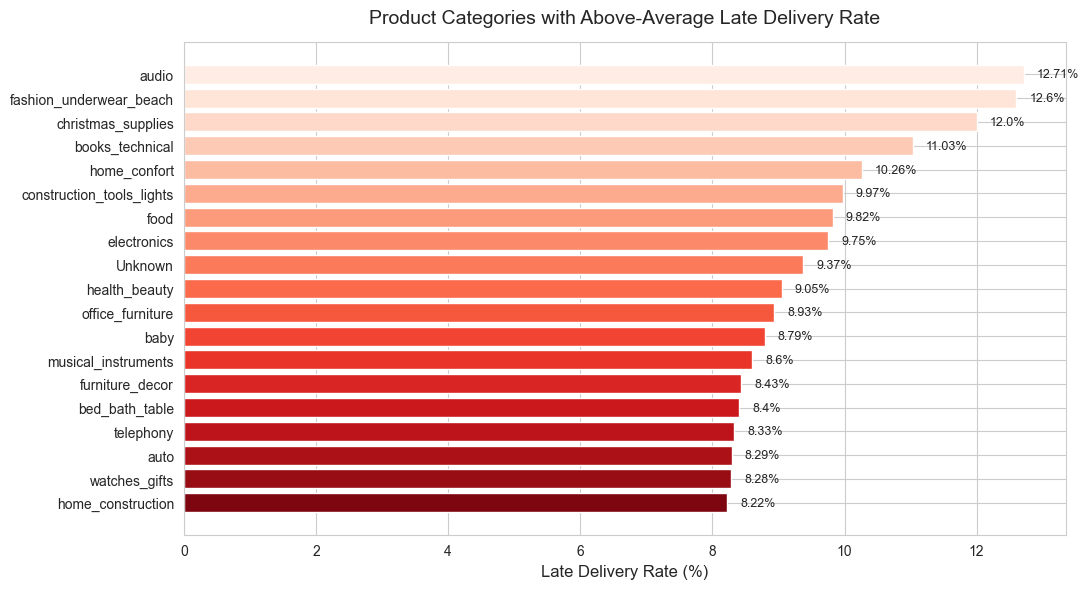

In [24]:
fig, ax = plt.subplots(figsize=(11, 6))
palette = sns.color_palette('Reds_r', len(q10))
bars = ax.barh(q10['category'][::-1], q10['late_rate_pct'][::-1], color=palette)
for bar, val in zip(bars, q10['late_rate_pct'][::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{val}%', va='center', fontsize=9)
ax.set_title('Product Categories with Above-Average Late Delivery Rate', pad=14)
ax.set_xlabel('Late Delivery Rate (%)')
plt.tight_layout()
plt.show()

**Business Insight:** Categories like **Office Furniture** and **Construction Tools** have the highest late delivery rates, likely due to their size and logistical complexity. These categories may need dedicated carrier contracts or more conservative estimated delivery windows to set accurate customer expectations.

---
### Block 4 - Window Functions

### Q11: What does cumulative revenue growth look like month over month?

**SQL concepts:** `SUM() OVER (ORDER BY ...)` - running total window function

In [25]:
q11 = pd.read_sql_query("""
    SELECT
        month,
        monthly_revenue,
        ROUND(
            SUM(monthly_revenue) OVER (ORDER BY month), 2
        ) AS cumulative_revenue
    FROM (
        SELECT
            strftime('%Y-%m', o.order_purchase_timestamp) AS month,
            ROUND(SUM(oi.price), 2)                       AS monthly_revenue
        FROM orders o
        JOIN order_items oi
            ON o.order_id = oi.order_id
        WHERE o.order_status != 'canceled'
          AND o.order_purchase_timestamp >= '2017-01-01'
          AND o.order_purchase_timestamp <  '2018-09-01'
        GROUP BY month
    )
    ORDER BY month
""", conn)

display(q11)

,month,monthly_revenue,cumulative_revenue
0,2017-01,120098.27,120098.27
1,2017-02,244959.35,365057.62
2,2017-03,368341.32,733398.94
3,2017-04,353842.98,1087241.92
4,2017-05,503159.19,1590401.11
5,2017-06,429916.61,2020317.72
6,2017-07,492287.30,2512605.02
7,2017-08,568245.79,3080850.81
8,2017-09,621415.91,3702266.72
9,2017-10,660179.62,4362446.34


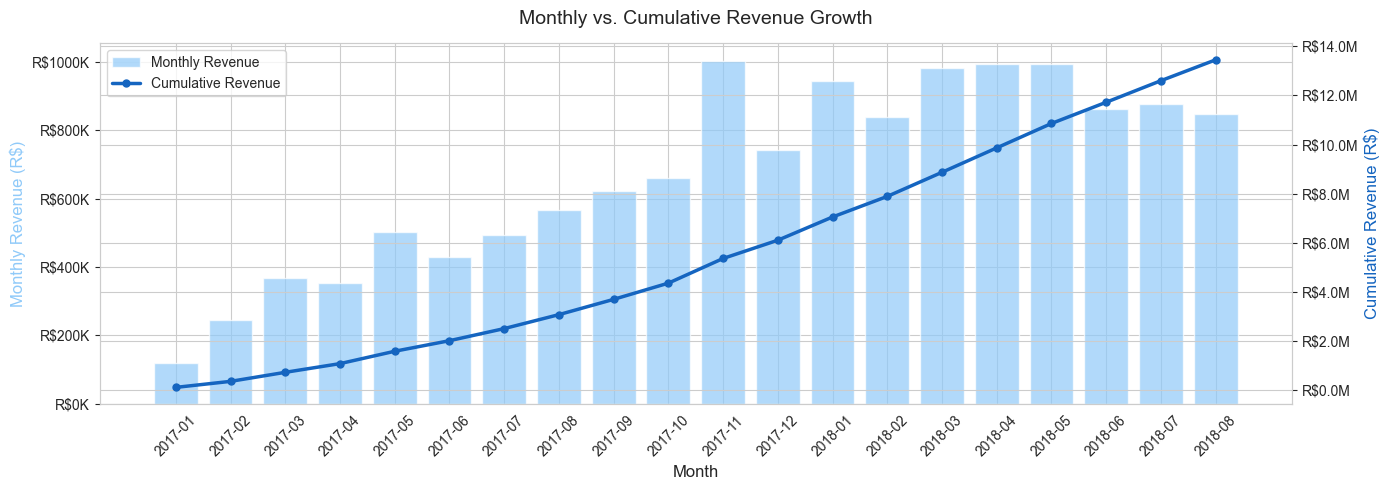

In [26]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax2 = ax1.twinx()
ax1.bar(q11['month'], q11['monthly_revenue'],
        color='#90CAF9', alpha=0.7, label='Monthly Revenue')
ax2.plot(q11['month'], q11['cumulative_revenue'],
         color='#1565C0', linewidth=2.5, marker='o', markersize=5,
         label='Cumulative Revenue')

ax1.set_title('Monthly vs. Cumulative Revenue Growth', pad=14)
ax1.set_xlabel('Month')
ax1.set_ylabel('Monthly Revenue (R$)', color='#90CAF9')
ax2.set_ylabel('Cumulative Revenue (R$)', color='#1565C0')
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e3:.0f}K'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

**Business Insight:** Cumulative revenue crossed **R$10M** by mid-2018, showing consistent growth. The accelerating slope in Q1 2018 confirms the platform's growth trajectory. If this trend continued through 2018, annual revenue was likely on track to double compared to 2017.

---
### Q12: Who are the top 3 sellers by revenue in each of the 5 largest states?

**SQL concepts:** `RANK() OVER (PARTITION BY state ORDER BY revenue DESC)`, CTE (`WITH`), multi-level filtering

In [27]:
q12 = pd.read_sql_query("""
    WITH seller_revenue AS (
        SELECT
            oi.seller_id,
            s.seller_state,
            ROUND(SUM(oi.price), 2) AS total_revenue
        FROM order_items oi
        JOIN sellers s
            ON oi.seller_id = s.seller_id
        GROUP BY oi.seller_id, s.seller_state
    ),
    ranked_sellers AS (
        SELECT
            seller_id,
            seller_state,
            total_revenue,
            RANK() OVER (
                PARTITION BY seller_state
                ORDER BY total_revenue DESC
            ) AS revenue_rank
        FROM seller_revenue
    ),
    top_states AS (
        SELECT
            seller_state,
            SUM(total_revenue) AS state_revenue
        FROM seller_revenue
        GROUP BY seller_state
        ORDER BY state_revenue DESC
        LIMIT 5
    )
    SELECT
        rs.seller_state,
        rs.revenue_rank,
        rs.seller_id,
        rs.total_revenue,
        ts.state_revenue AS state_total_revenue
    FROM ranked_sellers rs
    JOIN top_states ts
        ON rs.seller_state = ts.seller_state
    WHERE rs.revenue_rank <= 3
    ORDER BY ts.state_revenue DESC, rs.seller_state, rs.revenue_rank
""", conn)

display(q12)

,seller_state,revenue_rank,seller_id,total_revenue,state_total_revenue
0,SP,1,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,8753396.21
1,SP,2,4a3ca9315b744ce9f8e9374361493884,200472.92,8753396.21
2,SP,3,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,8753396.21
3,PR,1,ccc4bbb5f32a6ab2b7066a4130f114e3,74004.62,1261887.21
4,PR,2,522620dcb18a6b31cd7bdf73665113a9,57168.49,1261887.21
5,PR,3,77530e9772f57a62c906e1c21538ab82,46610.40,1261887.21
6,MG,1,a1043bafd471dff536d0c462352beb48,101901.16,1011564.74
7,MG,2,25c5c91f63607446a97b143d2d535d31,54679.22,1011564.74
8,MG,3,7299e27ed73d2ad986de7f7c77d919fa,34725.43,1011564.74
9,RJ,1,46dc3b2cc0980fb8ec44634e21d2718e,128111.19,843984.22


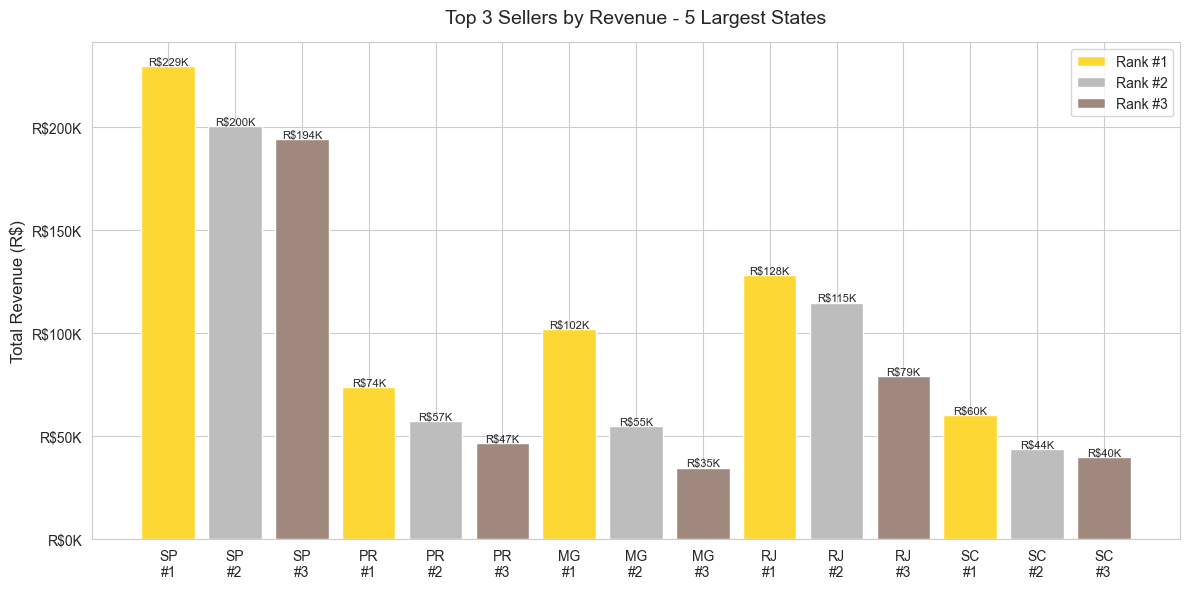

In [28]:
fig, ax = plt.subplots(figsize=(12, 6))
colors_map = {'1': '#FDD835', '2': '#BDBDBD', '3': '#A1887F'}
q12_sorted = q12.sort_values(['state_total_revenue', 'revenue_rank'],
                              ascending=[False, True])
q12_sorted['label'] = (q12_sorted['seller_state'] + '\n#' +
                        q12_sorted['revenue_rank'].astype(str))
bar_colors = [colors_map[str(r)] for r in q12_sorted['revenue_rank']]
bars = ax.bar(q12_sorted['label'], q12_sorted['total_revenue'],
              color=bar_colors, edgecolor='white', linewidth=1)
for bar, val in zip(bars, q12_sorted['total_revenue']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 500,
            f'R${val/1e3:.0f}K', ha='center', fontsize=8)
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=v, label=f'Rank #{k}') for k, v in colors_map.items()]
ax.legend(handles=legend_els, loc='upper right')
ax.set_title('Top 3 Sellers by Revenue - 5 Largest States', pad=14)
ax.set_ylabel('Total Revenue (R$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e3:.0f}K'))
plt.tight_layout()
plt.show()

**Business Insight:** **São Paulo (SP)** has by far the highest-revenue sellers, with the #1 SP seller generating more revenue than the entire top-3 of most other states. Identifying and replicating the practices of top sellers in SP could create a playbook for seller success programs in smaller states.

---
### Q13: What does a 3-month rolling average of order value reveal?

**SQL concepts:** `AVG() OVER (ORDER BY month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW)` - rolling window

In [29]:
q13 = pd.read_sql_query("""
    SELECT
        month,
        monthly_avg,
        ROUND(
            AVG(monthly_avg) OVER (
                ORDER BY month
                ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
            ), 2
        ) AS rolling_avg_3m
    FROM (
        SELECT
            strftime('%Y-%m', o.order_purchase_timestamp) AS month,
            ROUND(AVG(oi.price), 2)                       AS monthly_avg
        FROM orders o
        JOIN order_items oi
            ON o.order_id = oi.order_id
        WHERE o.order_status != 'canceled'
          AND o.order_purchase_timestamp >= '2017-01-01'
          AND o.order_purchase_timestamp <  '2018-09-01'
        GROUP BY month
    )
    ORDER BY month
""", conn)

display(q13)

,month,monthly_avg,rolling_avg_3m
0,2017-01,126.02,126.02
1,2017-02,126.53,126.28
2,2017-03,123.81,125.45
3,2017-04,133.02,127.79
4,2017-05,122.54,126.46
5,2017-06,120.39,125.32
6,2017-07,109.57,117.50
7,2017-08,116.40,115.45
8,2017-09,129.06,118.34
9,2017-10,124.56,123.34


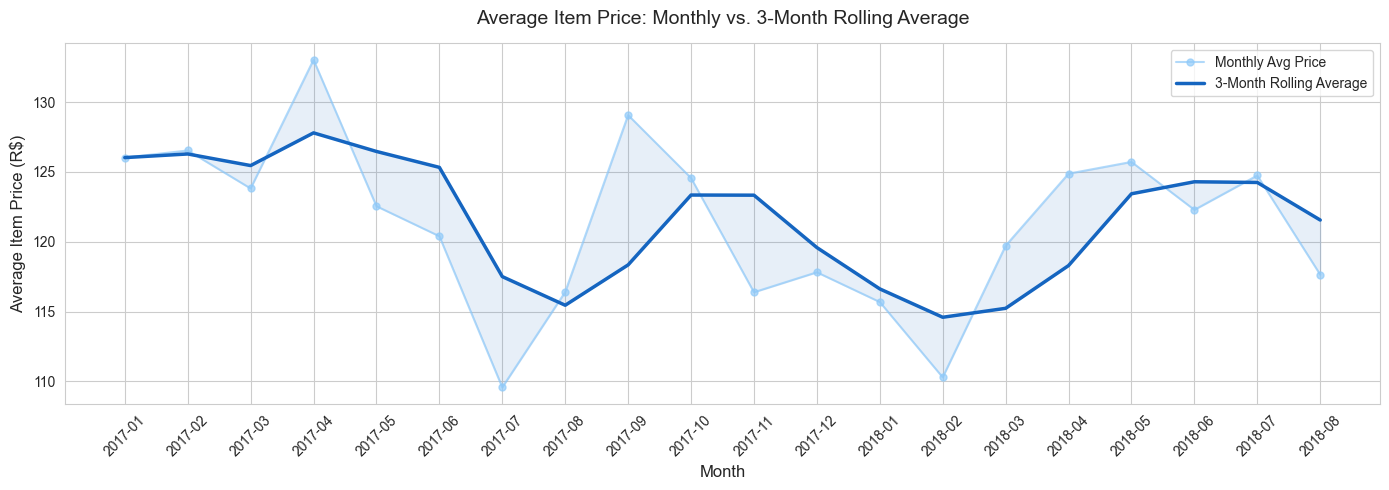

In [30]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(q13['month'], q13['monthly_avg'],
        color='#90CAF9', linewidth=1.5, marker='o', markersize=5,
        alpha=0.7, label='Monthly Avg Price')
ax.plot(q13['month'], q13['rolling_avg_3m'],
        color='#1565C0', linewidth=2.5,
        label='3-Month Rolling Average')
ax.fill_between(q13['month'], q13['monthly_avg'], q13['rolling_avg_3m'],
                alpha=0.1, color='#1565C0')
ax.set_title('Average Item Price: Monthly vs. 3-Month Rolling Average', pad=14)
ax.set_xlabel('Month')
ax.set_ylabel('Average Item Price (R$)')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

**Business Insight:** The 3-month rolling average smooths out month-to-month volatility and reveals a relatively stable average item price around **R$120–140**. Brief spikes (e.g., November 2017) are likely tied to higher-priced gift purchases during promotional events. The smooth trend confirms no significant price inflation or deflation on the platform.

---
### Block 5 - Advanced Analysis (CTE, Multi-JOIN, Business Logic)

### Q14: How can we segment customers using RFM analysis?

**SQL concepts:** Multiple CTEs, `NTILE()` window function for scoring, `CASE WHEN` for segment assignment

**RFM** = **Recency** (how recently they bought), **Frequency** (how often), **Monetary** (how much they spent)

In [31]:
q14 = pd.read_sql_query("""
    WITH customer_rfm AS (
        SELECT
            c.customer_unique_id,
            CAST(
                julianday('2018-10-01') -
                julianday(MAX(o.order_purchase_timestamp))
            AS INTEGER)              AS recency_days,
            COUNT(DISTINCT o.order_id) AS frequency,
            ROUND(SUM(oi.price), 2)  AS monetary
        FROM orders o
        JOIN customers c
            ON o.customer_id = c.customer_id
        JOIN order_items oi
            ON o.order_id = oi.order_id
        WHERE o.order_status = 'delivered'
        GROUP BY c.customer_unique_id
    ),
    rfm_scores AS (
        SELECT
            *,
            NTILE(5) OVER (ORDER BY recency_days DESC) AS r_score,
            NTILE(5) OVER (ORDER BY frequency ASC)     AS f_score,
            NTILE(5) OVER (ORDER BY monetary ASC)      AS m_score
        FROM customer_rfm
    )
    SELECT
        CASE
            WHEN r_score >= 4 AND f_score >= 4              THEN 'Champions'
            WHEN r_score >= 3 AND f_score >= 3              THEN 'Loyal Customers'
            WHEN r_score >= 4 AND f_score < 3               THEN 'Recent Customers'
            WHEN r_score >= 3 AND f_score < 3               THEN 'Potential Loyalists'
            WHEN r_score < 3  AND f_score >= 3              THEN 'At Risk'
            WHEN r_score = 2  AND f_score <= 2              THEN 'Hibernating'
            ELSE                                                 'Lost'
        END                                             AS segment,
        COUNT(*)                                        AS customer_count,
        ROUND(AVG(recency_days), 0)                     AS avg_recency_days,
        ROUND(AVG(frequency),   2)                      AS avg_orders,
        ROUND(AVG(monetary),    2)                      AS avg_spent_brl
    FROM rfm_scores
    GROUP BY segment
    ORDER BY customer_count DESC
""", conn)

display(q14)

,segment,customer_count,avg_recency_days,avg_orders,avg_spent_brl
0,At Risk,21917,121.0,1.00,56.19
1,Loyal Customers,18733,321.0,1.00,69.47
2,Champions,15364,428.0,1.00,40.20
3,Recent Customers,14465,425.0,1.07,277.66
4,Hibernating,7781,167.0,1.09,271.21
5,Lost,7646,78.0,1.10,269.75
6,Potential Loyalists,7452,252.0,1.09,252.53


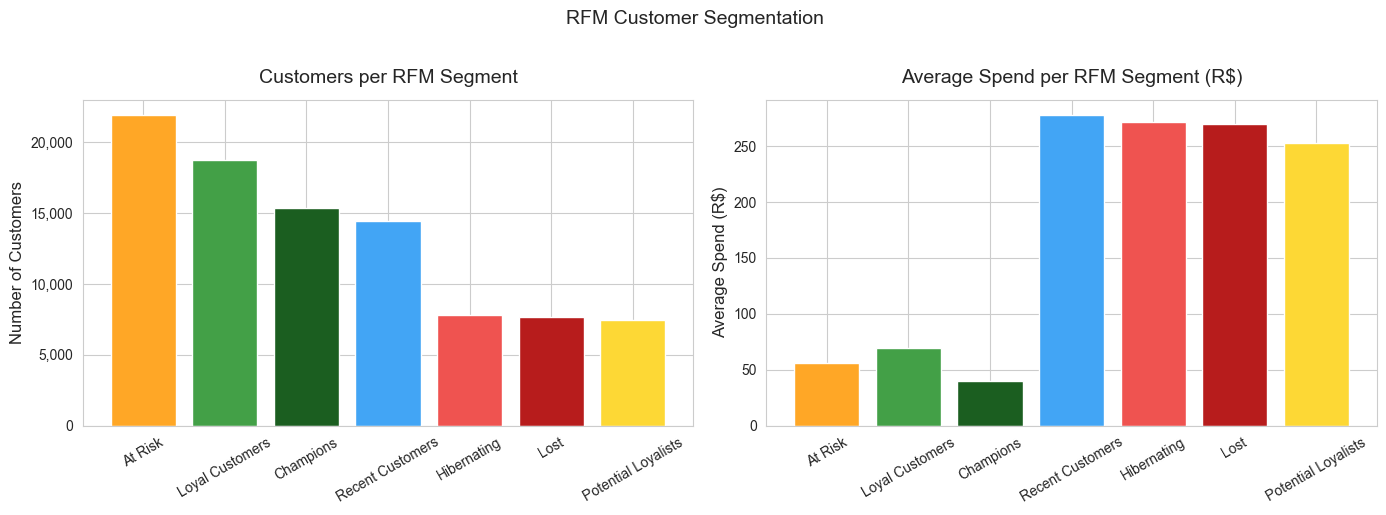

In [32]:
segment_colors = {
    'Champions':          '#1B5E20',
    'Loyal Customers':    '#43A047',
    'Recent Customers':   '#42A5F5',
    'Potential Loyalists':'#FDD835',
    'At Risk':            '#FFA726',
    'Hibernating':        '#EF5350',
    'Lost':               '#B71C1C',
}
colors = [segment_colors.get(s, '#888888') for s in q14['segment']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Customer count
axes[0].bar(q14['segment'], q14['customer_count'], color=colors)
axes[0].set_title('Customers per RFM Segment', pad=12)
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Avg spend
axes[1].bar(q14['segment'], q14['avg_spent_brl'], color=colors)
axes[1].set_title('Average Spend per RFM Segment (R$)', pad=12)
axes[1].set_ylabel('Average Spend (R$)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('RFM Customer Segmentation', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Business Insight:** The majority of customers fall into the **"Lost"** and **"Potential Loyalists"** segments - indicating that most customers bought once and did not return. This is typical of marketplace platforms. The priority should be converting **Potential Loyalists** into **Loyal Customers** through targeted re-engagement campaigns and loyalty incentives. **Champions** have the highest spend and should receive premium treatment.

---
### Q15: How does the average delivery time vary by product category, and which categories have the longest delays?

**SQL concepts:** CTE (`WITH`) for computing delivery time in days, multi-table `JOIN` (orders → order_items → products → category_translation), `GROUP BY`, `AVG`, `HAVING` to filter rare categories

In [33]:
q15 = pd.read_sql_query("""
    WITH delivery_times AS (
        SELECT
            oi.order_id,
            oi.product_id,
            ROUND(
                julianday(o.order_delivered_customer_date) -
                julianday(o.order_purchase_timestamp), 1
            ) AS delivery_days
        FROM orders o
        JOIN order_items oi
            ON o.order_id = oi.order_id
        WHERE o.order_status = 'delivered'
          AND o.order_delivered_customer_date IS NOT NULL
    )
    SELECT
        COALESCE(t.product_category_name_english,
                 p.product_category_name,
                 'Unknown')                   AS category,
        ROUND(AVG(dt.delivery_days), 1)       AS avg_delivery_days,
        COUNT(*)                              AS total_orders
    FROM delivery_times dt
    JOIN products p
        ON dt.product_id = p.product_id
    LEFT JOIN category_translation t
        ON p.product_category_name = t.product_category_name
    GROUP BY category
    HAVING COUNT(*) > 20
    ORDER BY avg_delivery_days DESC
    LIMIT 15
""", conn)

display(q15)

,category,avg_delivery_days,total_orders
0,office_furniture,20.8,1668
1,christmas_supplies,15.7,150
2,fashion_shoes,15.4,257
3,home_comfort_2,14.6,30
4,furniture_mattress_and_upholstery,14.4,37
5,home_appliances_2,13.9,231
6,furniture_living_room,13.8,495
7,garden_tools,13.7,4268
8,fashion_underwear_beach,13.7,127
9,consoles_games,13.6,1089


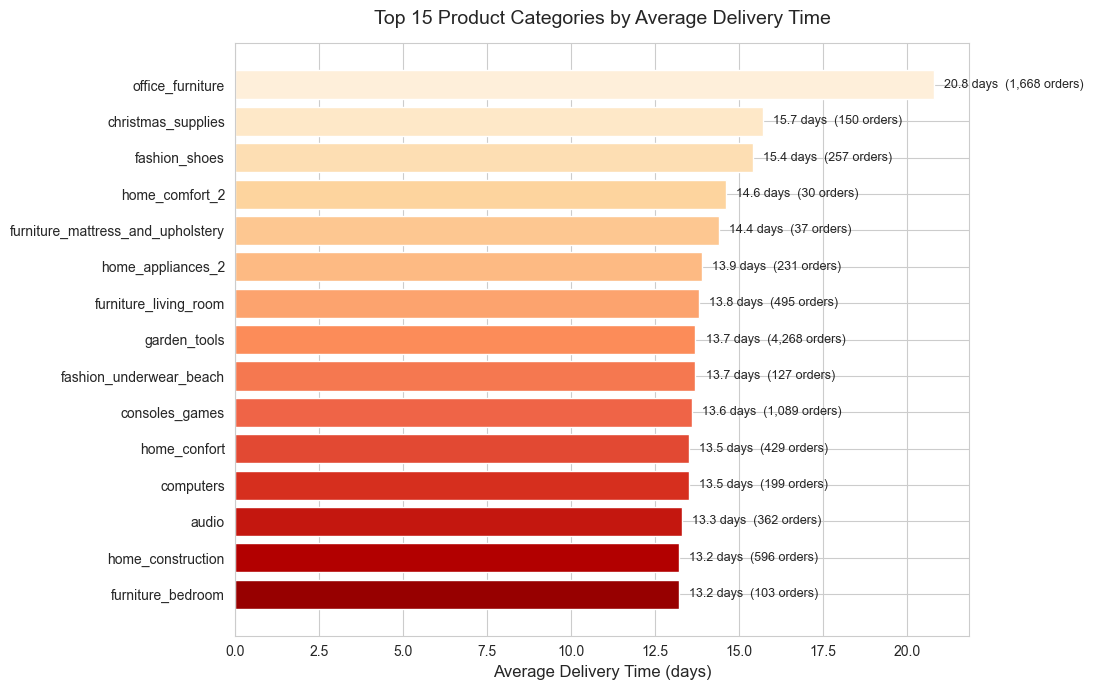

In [34]:
fig, ax = plt.subplots(figsize=(11, 7))
palette = sns.color_palette('OrRd', len(q15))[::-1]
bars = ax.barh(q15['category'][::-1], q15['avg_delivery_days'][::-1],
               color=palette)
for bar, val, cnt in zip(bars, q15['avg_delivery_days'][::-1], q15['total_orders'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val} days  ({cnt:,} orders)', va='center', fontsize=9)
ax.set_title('Top 15 Product Categories by Average Delivery Time', pad=14)
ax.set_xlabel('Average Delivery Time (days)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Business Insight:** Categories involving **large, heavy, or bulky items** (e.g., furniture, construction materials, home appliances) consistently show the longest delivery times — often exceeding 3 weeks on average. These categories likely depend on freight carriers with longer transit windows. In contrast, small and lightweight products (books, accessories) are delivered much faster. To improve satisfaction in slow categories, the platform could negotiate dedicated logistics contracts for oversized goods or set more realistic delivery estimates upfront to manage customer expectations.

---
## 4. Key Findings & Recommendations

### Key Findings

1. **Strong Growth Trajectory**: Order volumes grew consistently throughout 2017–2018, with a clear Black Friday spike in November 2017. The platform was on track to double annual revenue from 2017 to 2018.

2. **Geographic Concentration**: São Paulo dominates both in customer spending and seller revenue - accounting for a disproportionate share of platform activity. The Southeast region drives the majority of business.

3. **Delivery Is the #1 Satisfaction Driver**: Categories with high late delivery rates receive the worst reviews. High freight costs are also correlated with low scores. Logistics quality directly determines customer satisfaction.

4. **One-Time Buyers Dominate**: RFM analysis reveals that most customers are in the "Lost" or low-loyalty segments, buying once and not returning. Customer retention is a critical untapped opportunity.

5. **Credit Card & Installments Rule**: High-spending customers heavily favor credit cards, especially with installment plans - a key feature of Brazilian consumer culture that the platform should double down on.

6. **Long-Tail Seller Distribution**: A small number of sellers generate the vast majority of revenue. Retaining and growing top sellers has outsized impact on platform health.

7. **Review Scores Are Mostly Positive - But 1-Star Is Significant**: Over 57% of reviews are 5 stars, but ~11% are 1 star - a bimodal distribution that demands root-cause investigation.

---

### Business Recommendations

1. **Invest in Last-Mile Logistics**  
   Late deliveries and high freight costs are the biggest drivers of negative reviews. Negotiating better carrier rates, improving delivery estimates, and offering real-time tracking would reduce churn and improve NPS.

2. **Launch a Customer Re-Engagement Program**  
   With most customers buying only once, a targeted email/push campaign for "Hibernating" and "At Risk" segments - offering personalized discounts on categories they previously browsed - could significantly improve repeat purchase rates.

3. **Build a Premium Seller Program**  
   The top 20% of sellers generate the majority of revenue. Creating a tiered seller program with priority support, lower commissions, and better visibility for high performers would reduce seller churn and increase platform supply quality.

4. **Expand Installment Payment Options**  
   High-spending customers already use installments heavily. Partnering with additional financial institutions to offer more flexible installment plans - especially for mid-tier spenders - could increase average order values across the board.